# Análisis de tráfico

Programa que analiza una secuencia de vídeo de una carretera (alias `carretera` en `alias.txt`) y cuenta el número de vehículos que circulan en cada sentido.

## Cómo funciona

Sustractor de fondo MOG2 (igual que `backsub0.py`) + apertura (kernel 3×3) + dilatación (5×5) + `findContours`. Como la cámara está bastante lejos de la carretera, los vehículos son pequeños en imagen, así que `MINAREA=300` es bajo y eso también deja pasar ruido de fondo.

Para filtrarlo: un cruce solo cuenta si el track lleva al menos `MINHITS=5` frames seguidos detectado **y** ha recorrido `MINMOVE=20` px desde que apareció — el ruido parpadea sin desplazarse de verdad. El ROI con sliders ayuda también a descartar lo que no es la carretera.

El script es **`trafico.py`** (necesita ventana de OpenCV).

### Uso

```
./trafico.py --dev=carretera
```

Tecla `m` para ver/ocultar la máscara. Los sliders `x0, x1, y0, y1` definen la zona a analizar. Los resultados van a `trafico.csv` (`timestamp, sentido`).

## Análisis de los datos recogidos

Cargamos `trafico.csv` y representamos el número de vehículos por minuto en cada sentido, para detectar horas punta u otras situaciones de interés.

In [1]:
import csv
import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

times = {'R':[], 'L':[]}

with open('trafico.csv') as f:
    for row in csv.DictReader(f):
        t = datetime.datetime.fromisoformat(row['timestamp'])
        times[row['sentido']].append(t)

print(f'Cruces hacia la derecha: {len(times["R"])}')
print(f'Cruces hacia la izquierda: {len(times["L"])}')

Cruces hacia la derecha: 18
Cruces hacia la izquierda: 52


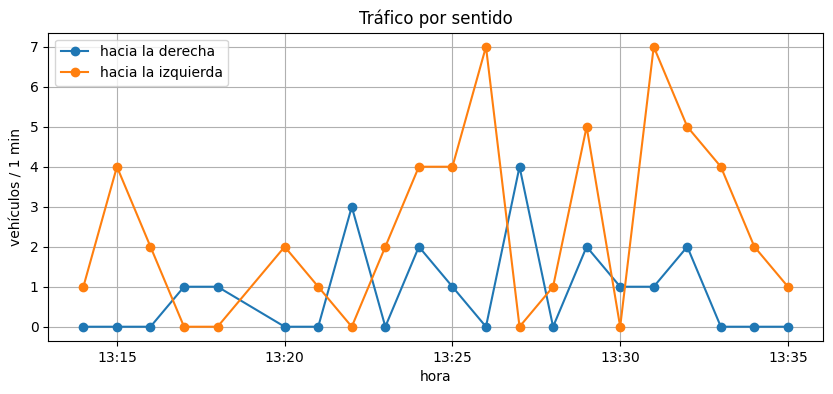

In [2]:
BIN = 1  # minutos por intervalo

def to_bins(ts, binsize=BIN):
    bins = {}
    for t in ts:
        key = t.replace(second=0, microsecond=0)
        key = key.replace(minute=binsize*(key.minute//binsize))
        bins[key] = bins.get(key, 0) + 1
    return bins

binsR = to_bins(times['R'])
binsL = to_bins(times['L'])

allkeys = sorted(set(binsR) | set(binsL))

plt.figure(figsize=(10,4))
plt.plot(allkeys, [binsR.get(k,0) for k in allkeys], '-o', label='hacia la derecha')
plt.plot(allkeys, [binsL.get(k,0) for k in allkeys], '-o', label='hacia la izquierda')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.xlabel('hora')
plt.ylabel(f'vehículos / {BIN} min')
plt.title('Tráfico por sentido')
plt.legend()
plt.grid(True)
plt.show()

## Imprecisiones
Una araña parece haber encontrado su hogar cerca de la lente de la cámara, por lo que genera algunas interferencias y falsos positivos.
Se ha intentado subsanar estableciendo un ROI (a mano, ajustable mediante sliders), para detectar solamente lo que pase por la carretera, aunque sigue sin ser 100% fiable, ya que la araña puede seguir pasando por esa zona. Aún así, se ha subsanado en gran medida el problema.

Podríamos mejorar la precisión utilizando técnicas de Machine Learning para clasificar los objetos detectados y sólo contabilizar los vehículos, pero eso va más allá del objetivo de este ejercicio.

## Ejemplo

In [3]:
import matplotlib.pyplot as plt
import cv2 as cv

def fig(w,h):
    plt.figure(figsize=(w,h))

def readrgb(file):
    return cv.cvtColor(cv.imread(file), cv.COLOR_BGR2RGB)

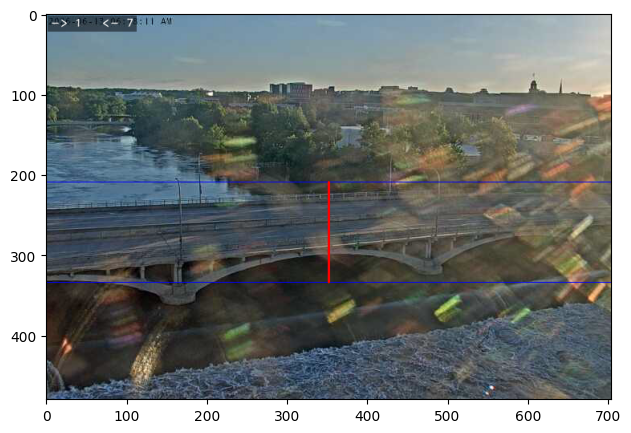

In [4]:
fig(12,5)
plt.imshow(readrgb('20260613-131811.png'))